# Greenland Ice Velocity Hagen Bræ tutorial
The PROMICE Ice Velocity product is a time-series of Greenland Ice Sheet velocity mosaics based on ESA Sentinel-1 SAR offset tracking (spatial resolution: 200 m). A new mosaic spanning 2 Sentinel-1A/-1B/-1C cycles is posted every 12 days, with each new mosaic supplied as a NetCDF file. The data product is described in detail in [Solgaard et al. (2021)](https://doi.org/10.5194/essd-13-3491-2021). We aim to make each new mosaic available within 10 days of the last included acquisition.

Here, we will look at how to query and fetch the dataset from our [Thredds server](https://thredds.geus.dk/), which is where we store and operationally update the PROMICE Ice Velocity product. Specifically, we will use the example of Hagen Bræ in Northwest Greenland to look at:
1. Connecting to the PROMICE Ice Velocity dataset file series using OpenDAP
2. Constructing and computing a velocity time-series from a flowline

So first, let's import all the packages we will be using.

In [ ]:
# For dataset loading and handling
import xarray as xr
import numpy as np

# For plotting
import matplotlib.pyplot as plt

# For filename fetching
from siphon.catalog import TDSCatalog
from datetime import datetime, timedelta
import re

## 1. Connecting to the PROMICE Ice Velocity dataset file series using OpenDAP
The PROMICE Ice Velocity product is available on the [GEUS Thredds server](https://thredds.geus.dk/) as a series of individual files representing each time step. First let's connect and fetch all files into a readable dataset using OpenDAP querying.

In [16]:
# Construct xml catalog
catalog_url = "https://thredds.geus.dk/thredds/catalog/IVdata/rotr/catalog.xml"
cat = TDSCatalog(catalog_url)

# Find OpenDAP file urls
urls = []
for name, ds in cat.datasets.items():
    if "OPENDAP" in ds.access_urls:
        urls.append(ds.access_urls["OPENDAP"])
print(f"Found {len(urls)} files")

# Print the latest 10 file names
urls[-10:]

Found 308 files


['https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20251031_20251124.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20251112_20251206.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20251124_20251218.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20251206_20251230.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20251218_20260111.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20251230_20260123.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20260111_20260204.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20260123_20260216.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20260204_20260228.nc',
 'https://thredds.geus.dk/thredds/dodsC/IVdata/rotr/IV_ROTR_V5_20260216_20260312.nc']

We now have a list of all the OpenDAP querable file URLs. These files all share the same spatial grid and work along a time coordinate, therefore we can safely combine them using Python's xarray package.

For this tutorial, let's extract the date range from the file URLs and only load files from the summer melt season (May to September) in 2025.

In [19]:
# Define start and end date
start = datetime(2025, 5, 1)
end = datetime(2025, 9, 1)

# Define function for extracting date range from file url
def extract_date_range(url):
    m = re.search(r'(\d{8})_(\d{8})\.nc$', url)
    if m:
        start_str, end_str = m.groups()
        s = datetime.strptime(start_str, "%Y%m%d")
        e = datetime.strptime(end_str, "%Y%m%d")
        return s, e
    else:
        return None, None

filtered_urls = []
for url in urls:
    s, e = extract_date_range(url)
    if s is None:
        continue
    # Include file if it overlaps target range
    if e >= start and s <= end:
        filtered_urls.append(url)

print("Files to load:")
for u in filtered_urls:
    print(u.split('/')[-1])


Files to load:
IV_ROTR_V5_20250410_20250504.nc
IV_ROTR_V5_20250422_20250516.nc
IV_ROTR_V5_20250504_20250528.nc
IV_ROTR_V5_20250516_20250609.nc
IV_ROTR_V5_20250528_20250621.nc
IV_ROTR_V5_20250609_20250703.nc
IV_ROTR_V5_20250621_20250715.nc
IV_ROTR_V5_20250703_20250727.nc
IV_ROTR_V5_20250715_20250808.nc
IV_ROTR_V5_20250727_20250820.nc
IV_ROTR_V5_20250808_20250901.nc
IV_ROTR_V5_20250820_20250913.nc
IV_ROTR_V5_20250901_20250925.nc


Right, we now have a list of file URLs that we can combine and open with xarray. Large queries over multiple time steps and big regions can often be costly in time and resources, so let's just visualise the first time slice in the dataset. So let's first open the first file url as a dataset and subset it spatially to our region of interest at Hagen Bræ.

In [28]:
# Define region of interest
x1=215000
x2=270000
y1=-890000
y2=-930000

# Open dataset and extract region
with xr.open_dataset(filtered_urls[0]) as ds:
    region = ds.sel(
                    x = slice(x1,x2),
                    y = slice(y1,y2),
    )

# Close connection to dataset
ds.close()
del ds

region


Note:Caching=1


<xarray.Dataset> Size: 2MB
Dimensions:                                  (time: 1, bnds: 2, y: 201, x: 276)
Coordinates:
  * time                                     (time) datetime64[ns] 8B 2025-04-22
  * y                                        (y) float64 2kB -8.9e+05 ... -9....
  * x                                        (x) float64 2kB 2.15e+05 ... 2.7...
Dimensions without coordinates: bnds
Data variables:
    crs                                      |S64 64B ...
    time_bnds                                (time, bnds) datetime64[ns] 16B ...
    land_ice_surface_easting_velocity        (time, y, x) float32 222kB ...
    land_ice_surface_northing_velocity       (time, y, x) float32 222kB ...
    land_ice_surface_vertical_velocity       (time, y, x) float32 222kB ...
    land_ice_surface_velocity_magnitude      (time, y, x) float32 222kB ...
    land_ice_surface_easting_velocity_std    (time, y, x) float32 222kB ...
    land_ice_surface_northing_velocity_std   (time, y, x) float32 222kB ...
    land_ice_surface_velocity_magnitude_std  (time, y, x) float32 222kB ...
Attributes:
    Conventions:                     CF-1.5
    time_coverage_start:             2025-04-10
    time_coverage_end:               2025-05-04
    sensors_used:                    Sentinel-1A,Sentinel-1C
    institution:                     GEUS
    methods_used:                    Offset-tracking
    calibration_method:              None
    title:                           Greenland Ice Velocity from 2025-04-10 t...
    summary:                         Greenland Ice Velocity from Sentinel-1 o...
    product_version:                 1.0
    DODS.strlen:                     0
    DODS_EXTRA.Unlimited_Dimension:  time

We can visualise this the horizontal surface velocity magnitude by selecting the appropriate variable and plotting it.

Note:Caching=1


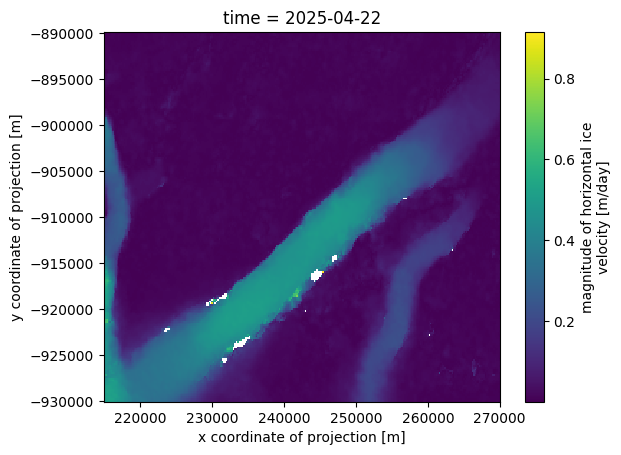

In [29]:
# Extract horizontal velocity magnitude at first time step
velocity_first = region["land_ice_surface_velocity_magnitude"].isel(time=0)

# Plot horizontal velocity magnitude at Hagen Brae for first time step
plt.figure()
velocity_first.plot()
plt.show()

## 2. Constructing and computing a velocity time-series from a flowline

Now let's generate a time-series of velocities across a flowline.

This flowline should be a one-dimensional line that represents a glacier's primary path of ice flow. We will firstly make a hypothetical flowline ourselves over the catchment of Hagen Bræ in Northeast Greenland. Then we will generate a velocity time-series over this flowline, capturing the average, minimum and maximum velocity.

Firstly, let's define our flowline as a set of predefined points. Then we will generate evenly spaced points along our flowline, and compute the cumulative distance along this. We'll plot it onto the first velocity field in our dataset, to see how it looks.

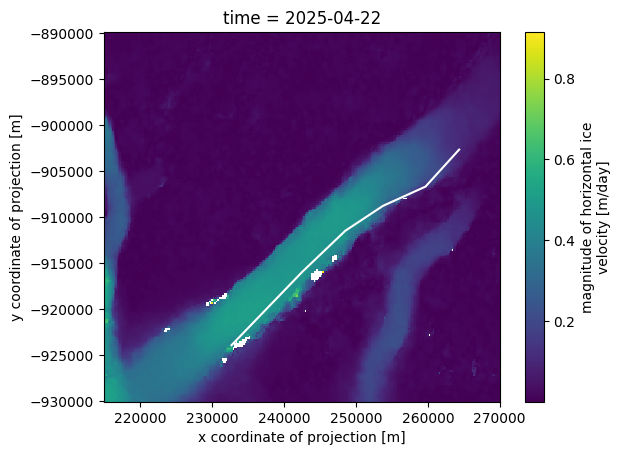

In [31]:
# Define flowline point locations
flowline_x = np.array([264352, 259672, 253754, 248511, 242556, 237624, 232692])
flowline_y = np.array([-902677, -906701, -908797, -911508, -915952, -919951, -923950])

# Plot overlaid line onto velocity magnitude
plt.figure()
velocity_first.plot()

# Overlay flowline point locations
plt.plot(flowline_x, flowline_y, c="white")

# Show plot
plt.show()

We can now extract velocity values at the nearest grid points of the dataset using a nearest neighbour interpolation, carried out by the Dataset object.

In [36]:
# Open dataset and extract region
with xr.open_mfdataset(filtered_urls, combine="by_coords", data_vars="all", chunks={}) as ds_all:
    subset = ds_all.sel(
        x = flowline_x,
        y = flowline_y,
        method="nearest"
    ).load()

# Close connection to dataset
ds_all.close()
del ds_all

flowline = subset["land_ice_surface_velocity_magnitude"]

Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1


<xarray.Dataset> Size: 19kB
Dimensions:                                  (time: 13, bnds: 2, y: 7, x: 7)
Coordinates:
  * time                                     (time) datetime64[ns] 104B 2025-...
  * y                                        (y) float64 56B -9.026e+05 ... -...
  * x                                        (x) float64 56B 2.644e+05 ... 2....
Dimensions without coordinates: bnds
Data variables:
    crs                                      (time) |S64 832B b'' b'' ... b''
    time_bnds                                (time, bnds) datetime64[ns] 208B dask.array<chunksize=(1, 2), meta=np.ndarray>
    land_ice_surface_easting_velocity        (time, y, x) float32 3kB dask.array<chunksize=(1, 7, 7), meta=np.ndarray>
    land_ice_surface_northing_velocity       (time, y, x) float32 3kB dask.array<chunksize=(1, 7, 7), meta=np.ndarray>
    land_ice_surface_vertical_velocity       (time, y, x) float32 3kB dask.array<chunksize=(1, 7, 7), meta=np.ndarray>
    land_ice_surface_velocity_magnitude      (time, y, x) float32 3kB dask.array<chunksize=(1, 7, 7), meta=np.ndarray>
    land_ice_surface_easting_velocity_std    (time, y, x) float32 3kB dask.array<chunksize=(1, 7, 7), meta=np.ndarray>
    land_ice_surface_northing_velocity_std   (time, y, x) float32 3kB dask.array<chunksize=(1, 7, 7), meta=np.ndarray>
    land_ice_surface_velocity_magnitude_std  (time, y, x) float32 3kB dask.array<chunksize=(1, 7, 7), meta=np.ndarray>
Attributes:
    Conventions:                     CF-1.5
    time_coverage_start:             2025-04-10
    time_coverage_end:               2025-05-04
    sensors_used:                    Sentinel-1A,Sentinel-1C
    institution:                     GEUS
    methods_used:                    Offset-tracking
    calibration_method:              None
    title:                           Greenland Ice Velocity from 2025-04-10 t...
    summary:                         Greenland Ice Velocity from Sentinel-1 o...
    product_version:                 1.0
    DODS.strlen:                     0
    DODS_EXTRA.Unlimited_Dimension:  time

If this approach is proving slow then we can also try and open each file individually and append subsetted values from only the variables needed.

In [43]:
flowline_datasets = []

# Iterate through file urls
for url in filtered_urls:
    try:

        # Open dataset and retain subset
        with xr.open_dataset(url, chunks={})[["land_ice_surface_velocity_magnitude"]] as ds:
            subset = ds.sel(
                x=flowline_x,
                y=flowline_y,
                method="nearest"
            ).load()
            flowline_datasets.append(subset)

    # Else raise exception and skip file url
    except Exception as e:
        print(f"Skipping {url}: {e}")

# Combine after extraction
flowline = xr.concat(flowline_datasets,
                     dim="time",
                     data_vars="all")
flowline

Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1
Note:Caching=1


<xarray.Dataset> Size: 3kB
Dimensions:                              (time: 13, y: 7, x: 7)
Coordinates:
  * time                                 (time) datetime64[ns] 104B 2025-04-2...
  * y                                    (y) float64 56B -9.026e+05 ... -9.24...
  * x                                    (x) float64 56B 2.644e+05 ... 2.326e+05
Data variables:
    land_ice_surface_velocity_magnitude  (time, y, x) float32 3kB 0.1046 ... ...
Attributes:
    Conventions:                     CF-1.5
    time_coverage_start:             2025-04-10
    time_coverage_end:               2025-05-04
    sensors_used:                    Sentinel-1A,Sentinel-1C
    institution:                     GEUS
    methods_used:                    Offset-tracking
    calibration_method:              None
    title:                           Greenland Ice Velocity from 2025-04-10 t...
    summary:                         Greenland Ice Velocity from Sentinel-1 o...
    product_version:                 1.0
    DODS.strlen:                     0
    DODS_EXTRA.Unlimited_Dimension:  time

And then we can plot our velocity profile along the flowline, specifically plotting time versus flowline velocity (average, maximum and minimum).

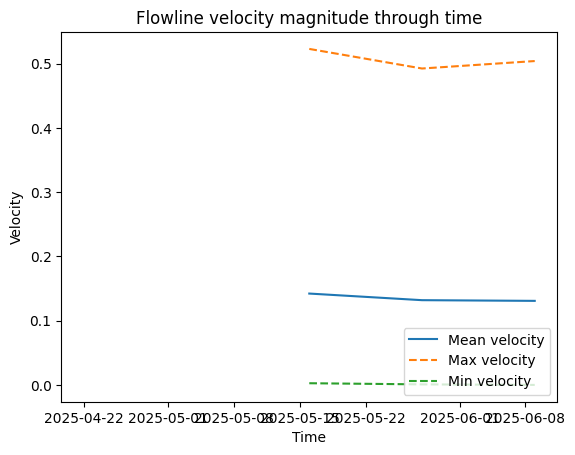

In [57]:
#print(flowline)
flowline_velocities = flowline["land_ice_surface_velocity_magnitude"].values

mean = []
min = []
max = []
for i in flowline_velocities:
    mean.append(np.mean(i))
    min.append(np.min(i))
    max.append(np.max(i))

plt.figure()

plt.plot(flowline.time, mean, label="Mean velocity")
plt.plot(flowline.time, max, "--", label="Max velocity")
plt.plot(flowline.time, min, "--", label="Min velocity")

plt.legend(loc="lower right")
plt.title("Flowline velocity magnitude through time")
plt.xlabel("Time")
plt.ylabel("Velocity")

plt.show()